In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/inventory-optimization-ml-or

Mounted at /content/drive
/content/drive/MyDrive/inventory-optimization-ml-or


In [2]:
!pwd
!ls

/content/drive/MyDrive/inventory-optimization-ml-or
data  notebooks  outputs  README.md  reports  requirements.txt	src


In [3]:
import pandas as pd

df = pd.read_csv("data/processed/features_phase2.csv")

print(df.shape)

(197925, 31)


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

df.head()

Shape: (197925, 31)

Columns:
Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
       'avg_demand', 'std_demand', 'cv', 'zero_demand_ratio', 'sales', 'day',
       'd', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'day_of_week', 'is_weekend', 'month_num', 'quarter', 'year_num',
       'lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28',
       'rolling_std_7', 'rolling_std_28'],
      dtype='object')

Data Types:
id                    object
item_id               object
dept_id               object
cat_id                object
store_id              object
state_id              object
avg_demand           float64
std_demand           float64
cv                   float64
zero_demand_ratio    float64
sales                  int64
day                    int64
d                     object
date                  object
wm_yr_wk               int64
weekday               object
wday                   int64
month                  int64
year       

,id,item_id,dept_id,cat_id,store_id,state_id,avg_demand,std_demand,cv,zero_demand_ratio,...,month_num,quarter,year_num,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,rolling_std_28
0,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,2,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,2,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,2,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,3,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,3,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.isnull().sum()

,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
avg_demand,0
std_demand,0
cv,0
zero_demand_ratio,0


In [6]:
max_day = df['day'].max()

test_days = 28

train_df = df[df['day'] <= max_day - test_days]

test_df = df[df['day'] > max_day - test_days]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (194985, 31)
Test shape: (2940, 31)


A time-based train-test split was used instead of a random split to preserve the temporal nature of the forecasting problem. The most recent 28 days were reserved for testing while all previous observations were used for training.

In [7]:
features = [
    'lag_1',
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'rolling_std_7',
    'rolling_std_28',
    'day_of_week',
    'is_weekend',
    'month_num'
]

target = 'sales'

In [12]:
x_train = train_df[features]
y_train = train_df[target]

x_test = test_df[features]
y_test = test_df[target]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (194985, 10)
y_train: (194985,)
x_test: (2940, 10)
y_test: (2940,)


In [10]:
!pip install lightgbm -q

In [18]:
import matplotlib.pyplot as plt

In [13]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(
    x_train,
    y_train
)

print("Model training completed!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 194985, number of used features: 10
[LightGBM] [Info] Start training from score 0.682052
Model training completed!


In [14]:
y_pred = model.predict(x_test)

print(y_pred[:10])

[0.08792677 0.08792677 0.08792677 0.08792677 0.10464884 0.13013336
 0.13013336 0.08792677 0.08792677 0.08792677]


In [15]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("RMSE :", rmse)
print("MAE  :", mae)

RMSE : 1.7857107412023754
MAE  : 0.8252648186749197


In [16]:
imp_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

imp_df = imp_df.sort_values(
    by="importance",
    ascending=False
)

imp_df

,feature,importance
4,rolling_mean_28,570
3,rolling_mean_7,440
5,rolling_std_7,333
2,lag_28,331
0,lag_1,318
1,lag_7,305
6,rolling_std_28,261
7,day_of_week,226
9,month_num,216
8,is_weekend,0


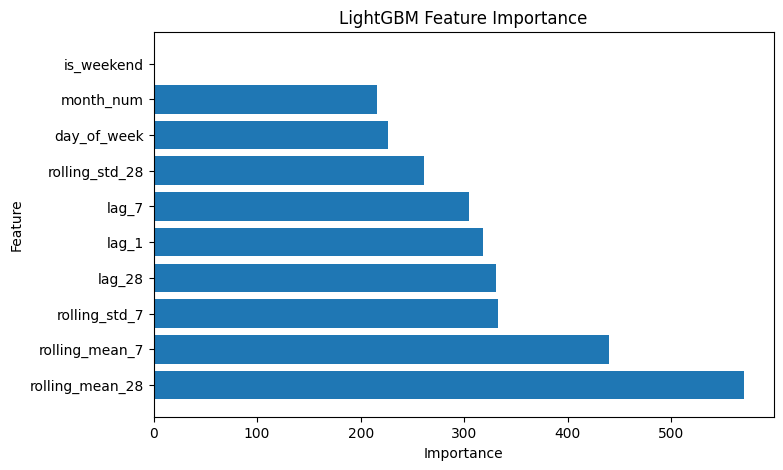

In [19]:
plt.figure(figsize=(8,5))

plt.barh(
    imp_df["feature"],
    imp_df["importance"]
)

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [20]:
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

comparison.head(20)

,actual,predicted
0,0,0.087927
1,0,0.087927
2,0,0.087927
3,0,0.087927
4,0,0.104649
5,0,0.130133
6,0,0.130133
7,0,0.087927
8,0,0.087927
9,0,0.087927


### Baseline Model Interpretation

The baseline LightGBM model produces small fractional forecasts such as 0.08–0.13 units, while actual demand is mostly zero with occasional discrete spikes. This reflects a key limitation of point forecasting under lumpy demand.

The model is effectively estimating an expected daily demand value rather than predicting the exact timing and magnitude of discrete demand events. For example, if a product sells 1 unit roughly once every 12 days, the average expected demand per day is close to 0.08 units.

From an inventory perspective, such fractional forecasts are difficult to act upon. A procurement manager cannot stock 0.08 units. Rounding down may cause stockouts during demand spikes, while rounding up may lead to excess inventory during long zero-demand periods.

The feature importance results show that rolling demand statistics and lag-based features dominate the model, while calendar variables such as weekend effects contribute little. This suggests that the sampled SKUs are primarily driven by intermittent event-like demand patterns rather than regular calendar-driven purchasing behavior.

These results motivate the next phase of the project: wrapping point forecasts with uncertainty intervals using Conformal Prediction. Instead of relying only on a single expected demand value, the proposed framework will generate statistically valid prediction intervals that can later be used for safety stock and inventory optimization decisions.

In [22]:
!find notebooks -name "*.ipynb"

notebooks/03_baseline_modeling.ipynb
notebooks/01_demand_analysis.ipynb
notebooks/02_feature_engineering.ipynb


In [23]:
!git status

Refresh index: 100% (5/5), done.
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/03_baseline_modeling.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [25]:
!git config --global user.email "smrititubid@gmail.com"

!git config --global user.name "smrititubid-afk"

In [26]:
!git add notebooks/03_baseline_modeling.ipynb

!git commit -m "Phase 2.2 baseline forecasting with LightGBM"

!git push origin main

[main cf98a70] Phase 2.2 baseline forecasting with LightGBM
 1 file changed, 1 insertion(+)
 create mode 100644 notebooks/03_baseline_modeling.ipynb
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 2.48 KiB | 318.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/smrititubid-afk/inventory-optimization-ml-or.git
   95b09d4..cf98a70  main -> main
